In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/skin-lesion-classifier"
for sub in ["notebooks", "models", "results"]:
    os.makedirs(f"{PROJECT_DIR}/{sub}", exist_ok=True)
print("Project folders ready in Drive.")

Mounted at /content/drive
Project folders ready in Drive.


In [1]:
!pip install -q --upgrade kaggle   # need >=1.8.0 for this token format

from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 8.2 MB/s eta 0:00:00


In [2]:
os.makedirs("/content/data/raw", exist_ok=True)
%cd /content/data/raw
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip -d ham10000
%cd /content

/content/data/raw
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [04:16<00:00, 21.7MB/s]

/content


In [3]:
# make 2 folders into 1
import os
os.makedirs("/content/data/processed/images", exist_ok=True)
!cp /content/data/raw/ham10000/HAM10000_images_part_1/*.jpg /content/data/processed/images/
!cp /content/data/raw/ham10000/HAM10000_images_part_2/*.jpg /content/data/processed/images/
!ls /content/data/processed/images | wc -l   # should print 10015

10015


(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
unique lesions: 7470
unique images: 10015


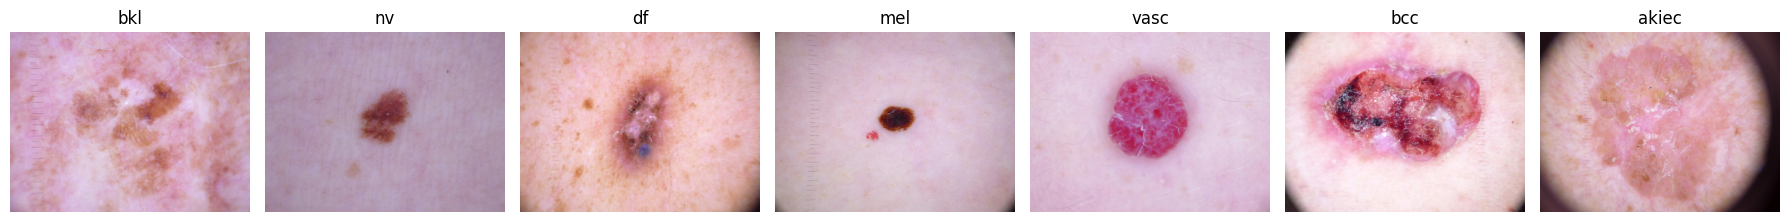

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

meta = pd.read_csv("/content/data/raw/ham10000/HAM10000_metadata.csv")

print(meta.shape)
display(meta.head())
print(meta["dx"].value_counts())
print("unique lesions:", meta["lesion_id"].nunique())
print("unique images:", meta["image_id"].nunique())

fig, axes = plt.subplots(1, 7, figsize=(18, 3))
for ax, dx_class in zip(axes, meta["dx"].unique()):
    row = meta[meta["dx"] == dx_class].iloc[0]
    img = Image.open(f"/content/data/processed/images/{row['image_id']}.jpg")
    ax.imshow(img)
    ax.set_title(dx_class)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [5]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs("/content/drive/MyDrive/skin-lesion-classifier/results", exist_ok=True)
meta.to_csv("/content/drive/MyDrive/skin-lesion-classifier/results/metadata_day1.csv", index=False)
fig.savefig("/content/drive/MyDrive/skin-lesion-classifier/results/sample_grid_day1.png")

Mounted at /content/drive


In [6]:
print(meta.isna().sum())#looking for missing data

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


In [7]:
age_by_class = meta.groupby("dx")["age"].describe()
print(age_by_class)

        count       mean        std   min   25%   50%   75%   max
dx                                                               
akiec   327.0  66.529052  11.476232  30.0  60.0  70.0  75.0  85.0
bcc     514.0  66.828794  13.656959  20.0  60.0  70.0  75.0  85.0
bkl    1089.0  64.283747  14.120715   0.0  55.0  65.0  75.0  85.0
df      115.0  53.043478  13.551326  25.0  45.0  50.0  65.0  80.0
mel    1111.0  60.679568  15.189847   5.0  50.0  60.0  70.0  85.0
nv     6660.0  46.477477  15.183275   0.0  35.0  45.0  55.0  85.0
vasc    142.0  51.373239  21.644651   0.0  40.0  55.0  70.0  85.0


In [8]:
#counting combonations of two catagories
sex_by_class = pd.crosstab(meta["dx"], meta["sex"])
print(sex_by_class)

# normalize=True turns raw counts into proportions, which matters here
# because classes are wildly different sizes (nv has ~6700 rows, df has ~115) —
# comparing raw counts across classes that size-mismatched is misleading
sex_by_class_pct = pd.crosstab(meta["dx"], meta["sex"], normalize="index")
print(sex_by_class_pct)

sex    female  male  unknown
dx                          
akiec     106   221        0
bcc       197   317        0
bkl       463   626       10
df         52    63        0
mel       424   689        0
nv       3237  3421       47
vasc       73    69        0
sex      female      male   unknown
dx                                 
akiec  0.324159  0.675841  0.000000
bcc    0.383268  0.616732  0.000000
bkl    0.421292  0.569609  0.009099
df     0.452174  0.547826  0.000000
mel    0.380952  0.619048  0.000000
nv     0.482774  0.510216  0.007010
vasc   0.514085  0.485915  0.000000


In [9]:
#image resolution consistancy
from PIL import Image
import random

# sample 200 random images instead of all 10,015 — checking every file is slow
# and a random sample is statistically enough to catch a mixed-resolution dataset
sample_ids = random.sample(list(meta["image_id"]), 200)

sizes = set()
for img_id in sample_ids:
    with Image.open(f"/content/data/processed/images/{img_id}.jpg") as img:
        sizes.add(img.size)   # img.size returns (width, height)

print(sizes)

{(600, 450)}


count    7470.000000
mean        1.340696
std         0.633970
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         6.000000
dtype: float64


<Axes: >

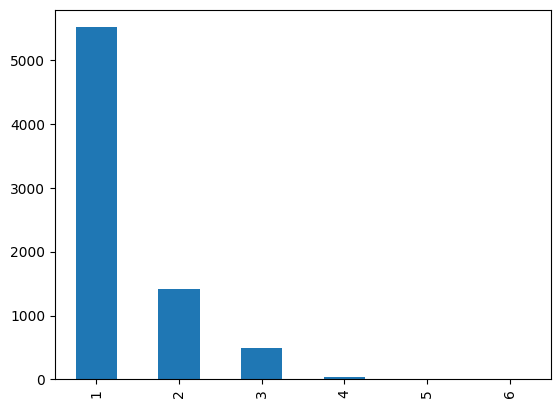

In [10]:
#quantifying leasion duplication
images_per_lesion = meta.groupby("lesion_id").size()
print(images_per_lesion.describe())

images_per_lesion.value_counts().sort_index().plot(kind="bar")

In [11]:
#age by diagnosis class
age_by_class = meta.groupby("dx")["age"].describe()
print(age_by_class)

        count       mean        std   min   25%   50%   75%   max
dx                                                               
akiec   327.0  66.529052  11.476232  30.0  60.0  70.0  75.0  85.0
bcc     514.0  66.828794  13.656959  20.0  60.0  70.0  75.0  85.0
bkl    1089.0  64.283747  14.120715   0.0  55.0  65.0  75.0  85.0
df      115.0  53.043478  13.551326  25.0  45.0  50.0  65.0  80.0
mel    1111.0  60.679568  15.189847   5.0  50.0  60.0  70.0  85.0
nv     6660.0  46.477477  15.183275   0.0  35.0  45.0  55.0  85.0
vasc    142.0  51.373239  21.644651   0.0  40.0  55.0  70.0  85.0


In [12]:
#localization by diagnosis class
pd.set_option("display.max_columns", None)

loc_by_class = pd.crosstab(meta["dx"], meta["localization"], normalize="index")
print(loc_by_class.round(3))

localization  abdomen  acral   back  chest    ear   face   foot  genital  \
dx                                                                         
akiec           0.015  0.000  0.089  0.037  0.009  0.346  0.000    0.000   
bcc             0.035  0.000  0.362  0.091  0.000  0.196  0.008    0.000   
bkl             0.038  0.000  0.184  0.067  0.005  0.290  0.001    0.002   
df              0.035  0.000  0.017  0.000  0.000  0.000  0.017    0.009   
mel             0.059  0.000  0.291  0.061  0.015  0.093  0.025    0.000   
nv              0.128  0.001  0.213  0.030  0.004  0.015  0.042    0.007   
vasc            0.190  0.000  0.155  0.042  0.000  0.056  0.000    0.000   

localization   hand  lower extremity   neck  scalp  trunk  unknown  \
dx                                                                   
akiec         0.040            0.199  0.031  0.043  0.003    0.000   
bcc           0.004            0.113  0.027  0.037  0.021    0.010   
bkl           0.013            0.15